# 🔬 Análise dos Filtros Aprendidos (LearnedWaveletDWT1D_QMF)

## Objetivo
Verificar se os filtros aprendidos pelo `LearnedWaveletDWT1D_QMF` atendem às propriedades
matemáticas de filtros wavelet válidos.

## Propriedades Verificadas
1. **Admissibilidade** – média zero do filtro high-pass (função mãe wavelet)
2. **Normalização** – norma L2 unitária dos filtros
3. **QMF (Quadrature Mirror Filter)** – relação $g[n] = (-1)^n h[L{-}1{-}n]$
4. **Perfect Reconstruction** – condição de Nyquist: $|H(\omega)|^2 + |H(\omega+\pi)|^2 = 2$
5. **Resposta em frequência** – filtro low-pass é passa-baixa e high-pass é passa-alta
6. **Ortogonalidade / Localização** – produto de escala e concentração tempo-frequência
7. **Comparação com wavelets clássicas** – vis-à-vis db2, db4, coif1, sym4
8. **Vanishing moments** – análise numérica do número de momentos nulos
9. **Decaimento espectral** – taxa de decaimento no domínio de frequência

In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pywt
import warnings
warnings.filterwarnings('ignore')

# Forçar uso da CPU (evitar OOM na GPU)
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

import tensorflow as tf
from tensorflow.keras.models import load_model

import sys
sys.path.append('.')
sys.path.append('../../models')
from LWT import LearnedWaveletDWT1D_QMF, LearnedWaveletPair1D_QMF

from config.experiment_config import RESULTS_DIR, MODELS_DIR, LEARNED_WAVELET_CONFIG

plt.style.use('seaborn-v0_8-whitegrid')
(RESULTS_DIR / 'filter_analysis').mkdir(parents=True, exist_ok=True)

print(f'TensorFlow: {tf.__version__}')
print(f'Dispositivos: {tf.config.list_physical_devices()}')
print('\u2705 Imports realizados com sucesso!')

2026-03-02 00:06:44.129332: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow: 2.20.0
Dispositivos: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
✅ Imports realizados com sucesso!


2026-03-02 00:06:47.365561: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2026-03-02 00:06:47.365588: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:160] env: CUDA_VISIBLE_DEVICES="-1"
2026-03-02 00:06:47.365593: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:163] CUDA_VISIBLE_DEVICES is set to -1 - this hides all GPUs from CUDA
2026-03-02 00:06:47.365597: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:171] verbose logging is disabled. Rerun with verbose logging (usually --v=1 or --vmodule=cuda_diagnostics=1) to get more diagnostic output from this module
2026-03-02 00:06:47.365601: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:176] retrieving CUDA diagnostic information for host: grafare-linux
2026-03-02 00:06:47.365604: I external/local_xla/xla/stream_executor/cuda

/cuda_diagnostics.cc:183] hostname: grafare-linux
2026-03-02 00:06:47.365698: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:190] libcuda reported version is: 570.133.7
2026-03-02 00:06:47.365715: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:194] kernel reported version is: 570.133.7
2026-03-02 00:06:47.365717: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:284] kernel version seems to match DSO: 570.133.7


## 1. Carregar Modelo Treinado e Extrair Filtros

In [2]:
# Estratégia rápida: construir APENAS a camada wavelet e carregar seus pesos
# do arquivo .keras (H5) sem instanciar o modelo completo

import zipfile, json, io, h5py

wavelet_config = LEARNED_WAVELET_CONFIG

# Construir camada wavelet standalone
wavelet_layer = LearnedWaveletDWT1D_QMF(
    levels=wavelet_config['levels'],
    kernel_size=wavelet_config['kernel_size'],
    wavelet_net_units=wavelet_config['wavelet_net_units'],
    mode='coeffs',
    reg_energy=wavelet_config.get('reg_energy', 1e-2),
    reg_high_dc=wavelet_config.get('reg_high_dc', 1e-2),
    reg_smooth=wavelet_config.get('reg_smooth', 1e-3),
    normalize_low=wavelet_config.get('normalize_low', 'sum1'),
)

# Build com dummy input
dummy = tf.zeros((1, 256, 1))
_ = wavelet_layer(dummy)

# Extrair pesos do .keras (zip contendo model.weights.h5)
model_path = str(MODELS_DIR / 'learned_wavelet_cnn_best.keras')

with zipfile.ZipFile(model_path, 'r') as zf:
    h5_data = zf.read('model.weights.h5')

with h5py.File(io.BytesIO(h5_data), 'r') as f:
    pairs_group = f['layers/learned_wavelet_dwt1d_qmf/pairs']
    pair_names = sorted(pairs_group.keys())
    
    for i, (pair_name, pair) in enumerate(zip(pair_names, wavelet_layer.pairs)):
        pg = pairs_group[pair_name]
        
        # base_net: 2 Dense layers (kernel, bias each)
        d0_w = np.array(pg['base_net/layers/dense/vars/0'])
        d0_b = np.array(pg['base_net/layers/dense/vars/1'])
        d1_w = np.array(pg['base_net/layers/dense_1/vars/0'])
        d1_b = np.array(pg['base_net/layers/dense_1/vars/1'])
        
        # low_head: 1 Dense
        lh_w = np.array(pg['low_head/vars/0'])
        lh_b = np.array(pg['low_head/vars/1'])
        
        # raw_scale e translation
        raw_scale = np.array(pg['vars/0'])
        translation = np.array(pg['vars/1'])
        
        # Atribuir pesos
        pair.base_net.layers[0].set_weights([d0_w, d0_b])
        pair.base_net.layers[1].set_weights([d1_w, d1_b])
        pair.low_head.set_weights([lh_w, lh_b])
        pair.raw_scale.assign(raw_scale)
        pair.translation.assign(translation)
        
        print(f'  Pair {i} ({pair_name}): ✅ pesos carregados')

print(f'\n✅ Pesos carregados com sucesso ({len(pair_names)} pares)')

  Pair 0 (learned_wavelet_pair1d_qmf): ✅ pesos carregados
  Pair 1 (learned_wavelet_pair1d_qmf_1): ✅ pesos carregados

✅ Pesos carregados com sucesso (3 pares)


In [3]:
# Extrair filtros h e g de cada nível
def extract_filters(wavelet_layer):
    """Extrai filtros h e g de cada nível."""
    filters_per_level = []
    for i, pair in enumerate(wavelet_layer.pairs):
        t = pair._make_t()
        scale = tf.nn.softplus(pair.raw_scale) + 1e-3
        t_adj = (t - pair.translation) / scale
        
        z = pair.base_net(t_adj)
        h = pair.low_head(z)
        h = pair._normalize_h(h)
        g = pair._qmf_from_h(h)
        
        filters_per_level.append({
            'level': i + 1,
            'h': h.numpy().flatten(),
            'g': g.numpy().flatten(),
            'scale': scale.numpy(),
            'translation': pair.translation.numpy(),
            'kernel_size': pair.kernel_size,
            'normalize_low': pair.normalize_low,
        })
    return filters_per_level

filters = extract_filters(wavelet_layer)
n_levels = len(filters)
print(f'✅ {n_levels} níveis extraídos')
for f in filters:
    print(f"  Nível {f['level']}: kernel_size={f['kernel_size']}, "
          f"scale={f['scale']:.4f}, translation={f['translation']:.4f}")

✅ 2 níveis extraídos
  Nível 1: kernel_size=32, scale=0.5924, translation=-0.1595
  Nível 2: kernel_size=32, scale=0.7652, translation=-0.1327


## 2. Visualização dos Filtros no Domínio do Tempo

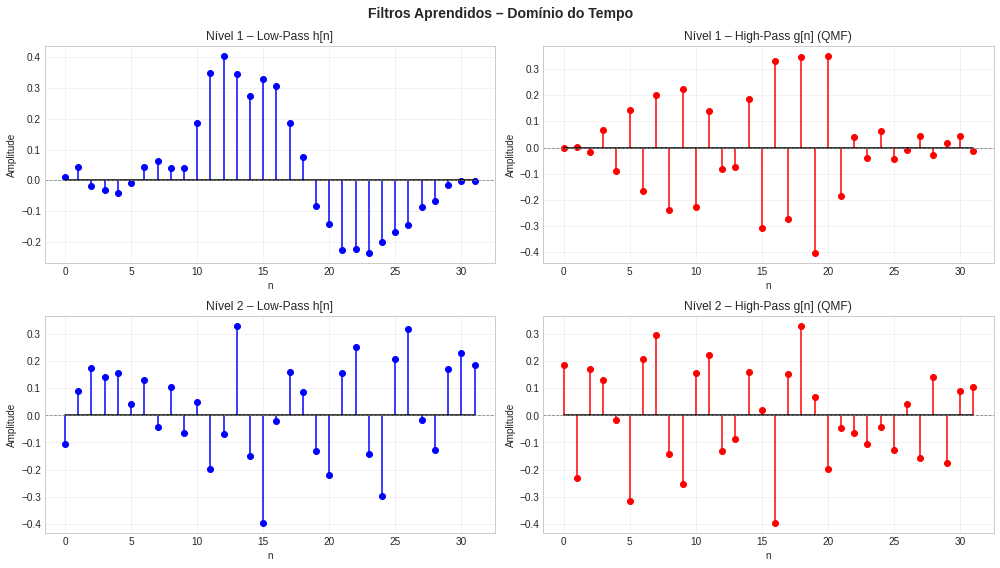

In [4]:
fig, axes = plt.subplots(n_levels, 2, figsize=(14, 4 * n_levels))
if n_levels == 1:
    axes = axes.reshape(1, -1)

for i, filt in enumerate(filters):
    # Low-pass h
    ax = axes[i, 0]
    ax.stem(filt['h'], linefmt='b-', markerfmt='bo', basefmt='k-')
    ax.set_title(f'Nível {filt["level"]} \u2013 Low-Pass h[n]')
    ax.set_xlabel('n')
    ax.set_ylabel('Amplitude')
    ax.axhline(0, color='gray', ls='--', lw=0.8)
    ax.grid(True, alpha=0.3)
    
    # High-pass g
    ax = axes[i, 1]
    ax.stem(filt['g'], linefmt='r-', markerfmt='ro', basefmt='k-')
    ax.set_title(f'Nível {filt["level"]} \u2013 High-Pass g[n] (QMF)')
    ax.set_xlabel('n')
    ax.set_ylabel('Amplitude')
    ax.axhline(0, color='gray', ls='--', lw=0.8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Filtros Aprendidos \u2013 Domínio do Tempo', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'filter_analysis' / 'filters_time_domain.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Propriedade 1 – Admissibilidade (Média Zero do High-Pass)

Uma função mãe wavelet $\psi$ deve satisfazer a **condição de admissibilidade**:
$$\int_{-\infty}^{\infty} \psi(t)\,dt = 0$$

No caso discreto, isso equivale a: $\sum_n g[n] = 0$

In [5]:
print('='*70)
print('PROPRIEDADE 1: Admissibilidade (média zero do high-pass)')
print('='*70)
print(f'{"Nível":>6} | {"sum(g)":>12} | {"mean(g)":>12} | {"Status":>12}')
print('-' * 55)

admissibility_results = []
for filt in filters:
    g_sum = np.sum(filt['g'])
    g_mean = np.mean(filt['g'])
    passed = np.abs(g_sum) < 1e-4
    status = '\u2705 OK' if passed else f'\u26a0\ufe0f  Dev={g_sum:.6f}'
    print(f"{filt['level']:>6} | {g_sum:>12.8f} | {g_mean:>12.8f} | {status:>12}")
    admissibility_results.append({'level': filt['level'], 'sum_g': g_sum, 'passed': passed})

PROPRIEDADE 1: Admissibilidade (média zero do high-pass)
 Nível |       sum(g) |      mean(g) |       Status
-------------------------------------------------------
     1 |  -0.00816879 |  -0.00025527 | ⚠️  Dev=-0.008169
     2 |  -0.01846516 |  -0.00057704 | ⚠️  Dev=-0.018465


## 4. Propriedade 2 – Normalização (Norma L2 e Soma)

Para filtros ortogonais válidos:
- $\|h\|_2 = 1$ (energia unitária para preservação de energia)
- $\sum_n h[n] = \sqrt{2}$ (condição de normalização para scaling function)
- $\|g\|_2 = 1$ (pelo QMF, decorre automaticamente de $\|h\|_2 = 1$)

In [6]:
print('='*70)
print('PROPRIEDADE 2: Normalização dos Filtros')
print('='*70)
sqrt2_label = 'sum(h)/√2'
print(f'{"Nível":>6} | {"||h||_2":>10} | {"||g||_2":>10} | {"sum(h)":>10} | {sqrt2_label:>10}')
print('-' * 65)

norm_results = []
for filt in filters:
    h_l2 = np.linalg.norm(filt['h'])
    g_l2 = np.linalg.norm(filt['g'])
    h_sum = np.sum(filt['h'])
    h_sum_ratio = h_sum / np.sqrt(2)
    print(f"{filt['level']:>6} | {h_l2:>10.6f} | {g_l2:>10.6f} | {h_sum:>10.6f} | {h_sum_ratio:>10.6f}")
    norm_results.append({
        'level': filt['level'],
        'h_l2': h_l2, 'g_l2': g_l2,
        'h_sum': h_sum, 'h_sum_over_sqrt2': h_sum_ratio
    })

print(f'\nNota: normalização usada = "{filters[0]["normalize_low"]}"')
print('  sum1 => sum(h)=1 (não é a convenção ortogonal clássica, mas preserva DC)')
print('  l2   => ||h||_2=1 (energia unitária)')

PROPRIEDADE 2: Normalização dos Filtros
 Nível |    ||h||_2 |    ||g||_2 |     sum(h) |  sum(h)/√2
-----------------------------------------------------------------
     1 |   1.026745 |   1.026745 |   1.000000 |   0.707107
     2 |   1.021337 |   1.021337 |   1.000000 |   0.707107

Nota: normalização usada = "sum1"
  sum1 => sum(h)=1 (não é a convenção ortogonal clássica, mas preserva DC)
  l2   => ||h||_2=1 (energia unitária)


## 5. Propriedade 3 – Relação QMF

O filtro high-pass é derivado do low-pass pela relação QMF:
$$g[n] = (-1)^n \cdot h[L{-}1{-}n]$$

Verificamos se essa relação é satisfeita (o que é garantido pela construção,
mas é bom confirmar numericamente).

In [7]:
print('='*70)
print('PROPRIEDADE 3: Relação QMF  g[n] = (-1)^n * h[L-1-n]')
print('='*70)

for filt in filters:
    h = filt['h']
    g = filt['g']
    K = len(h)
    
    # Reconstruir g esperado a partir de h
    sign = np.array([(-1)**n for n in range(K)])
    g_expected = h[::-1] * sign
    
    error = np.max(np.abs(g - g_expected))
    passed = error < 1e-6
    
    status = '\u2705 OK' if passed else f'\u274c Erro máx = {error:.2e}'
    print(f'  Nível {filt["level"]}: erro máximo = {error:.2e}  {status}')

PROPRIEDADE 3: Relação QMF  g[n] = (-1)^n * h[L-1-n]
  Nível 1: erro máximo = 0.00e+00  ✅ OK
  Nível 2: erro máximo = 0.00e+00  ✅ OK


## 6. Propriedade 4 – Perfect Reconstruction (Condição de Nyquist)

Para reconstruição perfeita com banco de filtros de 2 canais:
$$|H(e^{j\omega})|^2 + |H(e^{j(\omega+\pi)})|^2 = 2 \quad \forall \omega$$

Equivale a verificar que os **coeficientes de autocorrelação** de $h$ satisfazem:
$\sum_n h[n] h[n+2k] = \delta[k]$ (ortogonalidade com shifts pares).

PROPRIEDADE 4: Perfect Reconstruction (Nyquist / Power Complementarity)
  Nível 1: média=2.1073, desvio máx=406.89%  ⚠️  406.89%
  Nível 2: média=2.0852, desvio máx=441.95%  ⚠️  441.95%


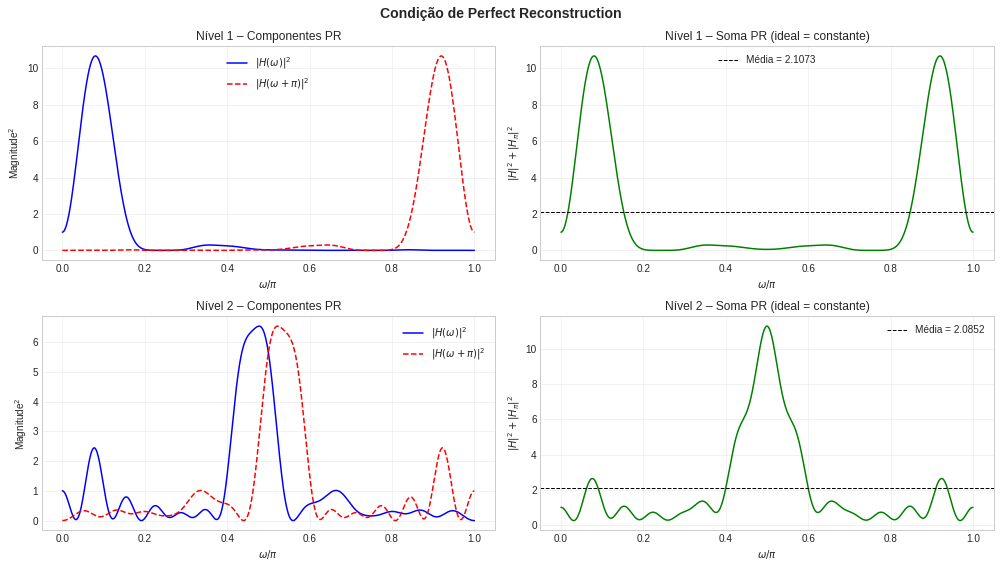

In [8]:
print('='*70)
print('PROPRIEDADE 4: Perfect Reconstruction (Nyquist / Power Complementarity)')
print('='*70)

N_freq = 1024
omega = np.linspace(0, np.pi, N_freq)

fig, axes = plt.subplots(n_levels, 2, figsize=(14, 4 * n_levels))
if n_levels == 1:
    axes = axes.reshape(1, -1)

pr_results = []
for i, filt in enumerate(filters):
    h = filt['h']
    K = len(h)
    
    # Resposta em frequência de h
    H = np.zeros(N_freq, dtype=complex)
    for n in range(K):
        H += h[n] * np.exp(-1j * omega * n)
    
    # H(omega + pi)
    H_shifted = np.zeros(N_freq, dtype=complex)
    for n in range(K):
        H_shifted += h[n] * np.exp(-1j * (omega + np.pi) * n)
    
    # Condição PR: |H|^2 + |H_shifted|^2 = constante
    pr_sum = np.abs(H)**2 + np.abs(H_shifted)**2
    pr_mean = np.mean(pr_sum)
    pr_deviation = np.max(np.abs(pr_sum - pr_mean)) / pr_mean * 100  # % desvio
    
    passed = pr_deviation < 5.0  # < 5% desvio
    status = '\u2705 OK' if passed else f'\u26a0\ufe0f  {pr_deviation:.2f}%'
    print(f'  Nível {filt["level"]}: média={pr_mean:.4f}, desvio máx={pr_deviation:.2f}%  {status}')
    
    pr_results.append({
        'level': filt['level'],
        'pr_mean': pr_mean,
        'pr_max_deviation_pct': pr_deviation,
        'passed': passed
    })
    
    # Plot |H|^2 e |H_shifted|^2
    ax = axes[i, 0]
    ax.plot(omega / np.pi, np.abs(H)**2, 'b-', label='$|H(\\omega)|^2$', lw=1.5)
    ax.plot(omega / np.pi, np.abs(H_shifted)**2, 'r--', label='$|H(\\omega+\\pi)|^2$', lw=1.5)
    ax.set_xlabel('$\\omega / \\pi$')
    ax.set_ylabel('Magnitude$^2$')
    ax.set_title(f'Nível {filt["level"]} \u2013 Componentes PR')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot soma (deveria ser constante)
    ax = axes[i, 1]
    ax.plot(omega / np.pi, pr_sum, 'g-', lw=1.5)
    ax.axhline(pr_mean, color='k', ls='--', lw=1, label=f'Média = {pr_mean:.4f}')
    ax.set_xlabel('$\\omega / \\pi$')
    ax.set_ylabel('$|H|^2 + |H_{\\pi}|^2$')
    ax.set_title(f'Nível {filt["level"]} \u2013 Soma PR (ideal = constante)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Condição de Perfect Reconstruction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'filter_analysis' / 'perfect_reconstruction.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Propriedade 5 – Autocorrelação e Ortogonalidade (Shifts Pares)

Para wavelets ortogonais, a autocorrelação do filtro $h$ com shifts pares deve ser um delta:
$$\sum_n h[n]\,h[n+2k] = \delta[k]$$

In [9]:
print('='*70)
print('PROPRIEDADE 5: Ortogonalidade (autocorrelação com shifts pares)')
print('='*70)

for filt in filters:
    h = filt['h']
    K = len(h)
    max_shift = K // 2
    
    print(f'\n  Nível {filt["level"]}:')
    print(f'    {"Shift 2k":>10} | {"<h, h_{2k}>":>14} | {"Ideal":>8} | {"Erro":>10}')
    print('    ' + '-' * 50)
    
    for k in range(max_shift + 1):
        shift = 2 * k
        if shift >= K:
            break
        # Inner product com shift
        overlap = min(K, K - shift)
        inner = np.sum(h[:overlap] * h[shift:shift + overlap]) if shift < K else 0.0
        ideal = 1.0 if k == 0 else 0.0
        error = abs(inner - ideal)
        marker = '\u2705' if error < 0.05 else '\u26a0\ufe0f '
        print(f'    {shift:>10} | {inner:>14.6f} | {ideal:>8.1f} | {error:>10.6f} {marker}')

PROPRIEDADE 5: Ortogonalidade (autocorrelação com shifts pares)

  Nível 1:
      Shift 2k |    <h, h_{2k}> |    Ideal |       Erro
    --------------------------------------------------
             0 |       1.054205 |      1.0 |   0.054205 ⚠️ 
             2 |       0.826029 |      0.0 |   0.826029 ⚠️ 
             4 |       0.453949 |      0.0 |   0.453949 ⚠️ 
             6 |       0.009311 |      0.0 |   0.009311 ✅
             8 |      -0.350770 |      0.0 |   0.350770 ⚠️ 
            10 |      -0.440413 |      0.0 |   0.440413 ⚠️ 
            12 |      -0.380889 |      0.0 |   0.380889 ⚠️ 
            14 |      -0.242802 |      0.0 |   0.242802 ⚠️ 
            16 |      -0.108974 |      0.0 |   0.108974 ⚠️ 
            18 |      -0.029107 |      0.0 |   0.029107 ✅
            20 |      -0.005751 |      0.0 |   0.005751 ✅
            22 |      -0.001148 |      0.0 |   0.001148 ✅
            24 |      -0.001385 |      0.0 |   0.001385 ✅
            26 |      -0.003668 |      0.0 

## 8. Propriedade 6 – Resposta em Frequência (Low-Pass / High-Pass)

Verificar que $h$ se comporta como um filtro passa-baixa e $g$ como passa-alta.

PROPRIEDADE 6: Resposta em Frequência
  Nível 1:
    h: 99.5% energia em baixa freq ✅
    g: 99.5% energia em alta freq  ✅
  Nível 2:
    h: 71.6% energia em baixa freq ✅
    g: 72.1% energia em alta freq  ✅


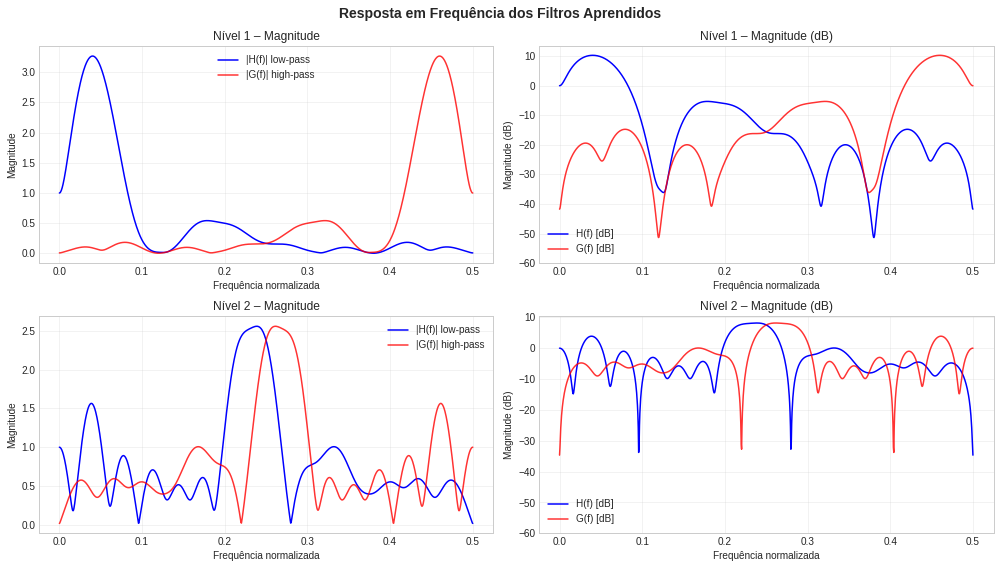

In [10]:
N_fft = 2048

fig, axes = plt.subplots(n_levels, 2, figsize=(14, 4 * n_levels))
if n_levels == 1:
    axes = axes.reshape(1, -1)

print('='*70)
print('PROPRIEDADE 6: Resposta em Frequência')
print('='*70)

for i, filt in enumerate(filters):
    h = filt['h']
    g = filt['g']
    
    H = np.fft.rfft(h, n=N_fft)
    G = np.fft.rfft(g, n=N_fft)
    freqs = np.fft.rfftfreq(N_fft)
    
    H_mag = np.abs(H)
    G_mag = np.abs(G)
    H_db = 20 * np.log10(H_mag + 1e-12)
    G_db = 20 * np.log10(G_mag + 1e-12)
    
    # Verificar: energia de h concentrada em baixa freq, g em alta freq
    half = len(freqs) // 2
    h_low_energy = np.sum(H_mag[:half]**2)
    h_high_energy = np.sum(H_mag[half:]**2)
    g_low_energy = np.sum(G_mag[:half]**2)
    g_high_energy = np.sum(G_mag[half:]**2)
    
    h_ratio = h_low_energy / (h_low_energy + h_high_energy + 1e-12)
    g_ratio = g_high_energy / (g_low_energy + g_high_energy + 1e-12)
    
    h_ok = '\u2705' if h_ratio > 0.6 else '\u26a0\ufe0f '
    g_ok = '\u2705' if g_ratio > 0.6 else '\u26a0\ufe0f '
    
    print(f'  Nível {filt["level"]}:')
    print(f'    h: {h_ratio*100:.1f}% energia em baixa freq {h_ok}')
    print(f'    g: {g_ratio*100:.1f}% energia em alta freq  {g_ok}')
    
    # Magnitude
    ax = axes[i, 0]
    ax.plot(freqs, H_mag, 'b-', label='|H(f)| low-pass', lw=1.5)
    ax.plot(freqs, G_mag, 'r-', label='|G(f)| high-pass', lw=1.5, alpha=0.8)
    ax.set_xlabel('Frequência normalizada')
    ax.set_ylabel('Magnitude')
    ax.set_title(f'Nível {filt["level"]} \u2013 Magnitude')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # dB
    ax = axes[i, 1]
    ax.plot(freqs, H_db, 'b-', label='H(f) [dB]', lw=1.5)
    ax.plot(freqs, G_db, 'r-', label='G(f) [dB]', lw=1.5, alpha=0.8)
    ax.set_xlabel('Frequência normalizada')
    ax.set_ylabel('Magnitude (dB)')
    ax.set_title(f'Nível {filt["level"]} \u2013 Magnitude (dB)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(bottom=-60)

plt.suptitle('Resposta em Frequência dos Filtros Aprendidos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'filter_analysis' / 'frequency_response.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Propriedade 7 – Vanishing Moments

O número de **momentos nulos** (vanishing moments) $N$ de uma wavelet $\psi$ é definido por:
$$\sum_n n^k \cdot g[n] = 0, \quad k = 0, 1, \ldots, N{-}1$$

Equivale ao número de zeros da função de transferência $G(z)$ em $z = 1$ ($\omega = 0$).
Quanto mais vanishing moments, melhor o filtro comprime polinômios de grau $< N$.

In [11]:
print('='*70)
print('PROPRIEDADE 7: Vanishing Moments do High-Pass g')
print('='*70)

vm_results = []
for filt in filters:
    g = filt['g']
    K = len(g)
    n_arr = np.arange(K, dtype=float)
    
    print(f'\n  Nível {filt["level"]}:')
    print(f'    {"Momento k":>10} | {"sum(n^k * g[n])":>18} | {"Status":>8}')
    print('    ' + '-' * 45)
    
    n_vanishing = 0
    for k in range(min(10, K)):
        moment = np.sum((n_arr ** k) * g)
        is_zero = np.abs(moment) < 1e-3
        marker = '\u2705' if is_zero else '\u274c'
        print(f'    {k:>10} | {moment:>18.8f} | {marker:>8}')
        if is_zero and k == n_vanishing:
            n_vanishing = k + 1
    
    vm_results.append({'level': filt['level'], 'vanishing_moments': n_vanishing})
    print(f'    \u27a1\ufe0f  Vanishing moments estimado: {n_vanishing}')

# Comparar com wavelets clássicas
print('\n  Referência (wavelets clássicas):')
for wname in ['db1', 'db2', 'db4', 'db8', 'coif1', 'sym4']:
    w = pywt.Wavelet(wname)
    print(f'    {wname:>6}: vanishing moments = {w.dec_len // 2}')

PROPRIEDADE 7: Vanishing Moments do High-Pass g

  Nível 1:
     Momento k |    sum(n^k * g[n]) |   Status
    ---------------------------------------------
             0 |        -0.00816878 |        ❌
             1 |         0.47069017 |        ❌
             2 |        26.17619798 |        ❌
             3 |       925.04817858 |        ❌
             4 |     29154.48558440 |        ❌
             5 |    885341.41154884 |        ❌
             6 |  26518049.51632253 |        ❌
             7 | 789402867.90101337 |        ❌
             8 | 23415070310.93035889 |        ❌
             9 | 692697219926.44274902 |        ❌
    ➡️  Vanishing moments estimado: 0

  Nível 2:
     Momento k |    sum(n^k * g[n]) |   Status
    ---------------------------------------------
             0 |        -0.01846512 |        ❌
             1 |        -5.38513444 |        ❌
             2 |      -130.14179461 |        ❌
             3 |     -2684.84971329 |        ❌
             4 |    -46474.767855

## 10. Comparação com Wavelets Clássicas

Comparar a forma dos filtros aprendidos com wavelets conhecidas (db2, db4, sym4, coif1).

In [12]:
# Wavelets clássicas para comparação
classic_wavelets = {
    'db2': pywt.Wavelet('db2'),
    'db4': pywt.Wavelet('db4'),
    'sym4': pywt.Wavelet('sym4'),
    'coif1': pywt.Wavelet('coif1'),
}

# Preparar filtros clássicos (interpolar para mesmo tamanho)
K_learned = filters[0]['kernel_size']

def resample_filter(f, target_len):
    """Reamostra filtro para target_len usando interpolação linear."""
    x_old = np.linspace(0, 1, len(f))
    x_new = np.linspace(0, 1, target_len)
    return np.interp(x_new, x_old, f)

# Calcular correlação entre filtros aprendidos e clássicos
print('='*70)
print('COMPARA\u00c7\u00c3O: Filtros Aprendidos vs Wavelets Clássicas')
print('='*70)
print('Correlação (Pearson) entre filtros low-pass:\n')

corr_data = []
for filt in filters:
    h_learned = filt['h']
    row = {'Level': filt['level']}
    for wname, w in classic_wavelets.items():
        h_classic = np.array(w.dec_lo)
        h_classic_resampled = resample_filter(h_classic, len(h_learned))
        # Normalizar ambos
        h_l = (h_learned - np.mean(h_learned)) / (np.std(h_learned) + 1e-12)
        h_c = (h_classic_resampled - np.mean(h_classic_resampled)) / (np.std(h_classic_resampled) + 1e-12)
        corr = np.corrcoef(h_l, h_c)[0, 1]
        row[wname] = corr
    corr_data.append(row)

corr_df = pd.DataFrame(corr_data)
print(corr_df.to_string(index=False))

# Melhor match
for _, row in corr_df.iterrows():
    wnames_only = {k: abs(v) for k, v in row.items() if k != 'Level'}
    best = max(wnames_only, key=wnames_only.get)
    print(f'  Nível {int(row["Level"])}: mais similar a {best} (|r| = {abs(row[best]):.4f})')

COMPARAÇÃO: Filtros Aprendidos vs Wavelets Clássicas
Correlação (Pearson) entre filtros low-pass:

 Level       db2       db4      sym4     coif1
     1 -0.318064 -0.810907  0.879586  0.072541
     2 -0.092272  0.118042 -0.252670 -0.278814
  Nível 1: mais similar a sym4 (|r| = 0.8796)
  Nível 2: mais similar a coif1 (|r| = 0.2788)


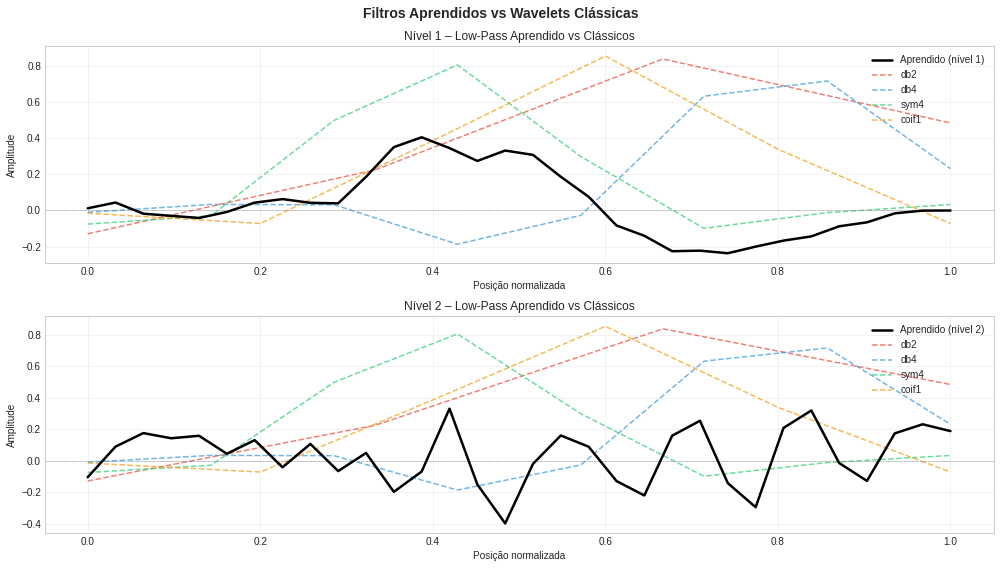

In [13]:
# Visualização: filtro aprendido vs clássicos (domínio do tempo)
fig, axes = plt.subplots(n_levels, 1, figsize=(14, 4 * n_levels))
if n_levels == 1:
    axes = [axes]

for i, filt in enumerate(filters):
    ax = axes[i]
    h_learned = filt['h']
    t_learned = np.linspace(0, 1, len(h_learned))
    
    ax.plot(t_learned, h_learned, 'k-', lw=2.5, label=f'Aprendido (nível {filt["level"]})', zorder=5)
    
    colors_classic = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
    for j, (wname, w) in enumerate(classic_wavelets.items()):
        h_classic = np.array(w.dec_lo)
        t_classic = np.linspace(0, 1, len(h_classic))
        ax.plot(t_classic, h_classic, '--', color=colors_classic[j], lw=1.5, alpha=0.7, label=wname)
    
    ax.set_title(f'Nível {filt["level"]} \u2013 Low-Pass Aprendido vs Clássicos')
    ax.set_xlabel('Posição normalizada')
    ax.set_ylabel('Amplitude')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='gray', ls='--', lw=0.5)

plt.suptitle('Filtros Aprendidos vs Wavelets Clássicas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'filter_analysis' / 'learned_vs_classic.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Comparação Espectral: Aprendido vs Clássicos

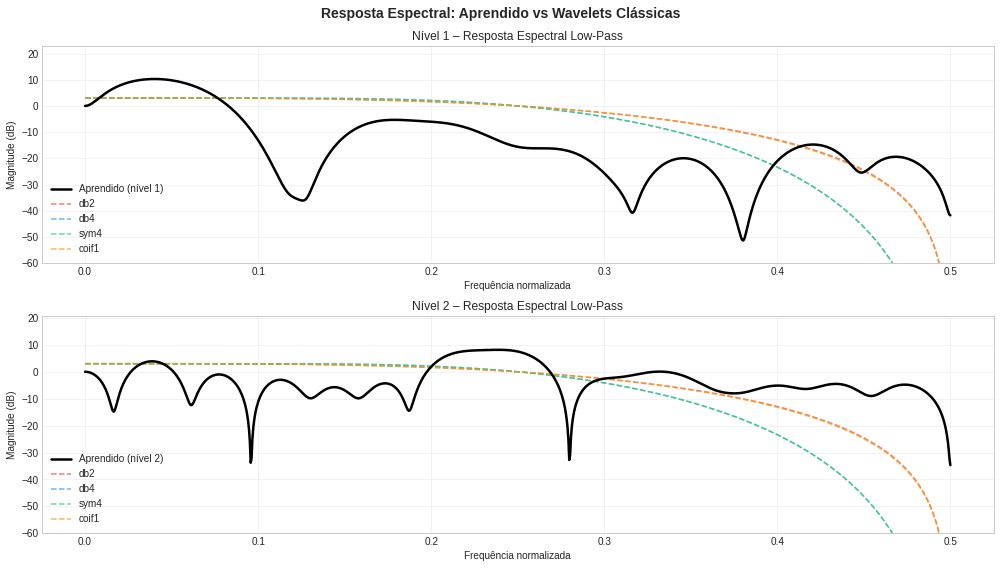

In [14]:
N_fft = 2048

fig, axes = plt.subplots(n_levels, 1, figsize=(14, 4 * n_levels))
if n_levels == 1:
    axes = [axes]

for i, filt in enumerate(filters):
    ax = axes[i]
    h_learned = filt['h']
    
    H_learned = np.abs(np.fft.rfft(h_learned, n=N_fft))
    freqs = np.fft.rfftfreq(N_fft)
    H_learned_db = 20 * np.log10(H_learned + 1e-12)
    
    ax.plot(freqs, H_learned_db, 'k-', lw=2.5, label=f'Aprendido (nível {filt["level"]})', zorder=5)
    
    colors_classic = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
    for j, (wname, w) in enumerate(classic_wavelets.items()):
        h_classic = np.array(w.dec_lo)
        H_classic = np.abs(np.fft.rfft(h_classic, n=N_fft))
        H_classic_db = 20 * np.log10(H_classic + 1e-12)
        ax.plot(freqs, H_classic_db, '--', color=colors_classic[j], lw=1.5, alpha=0.7, label=wname)
    
    ax.set_title(f'Nível {filt["level"]} \u2013 Resposta Espectral Low-Pass')
    ax.set_xlabel('Frequência normalizada')
    ax.set_ylabel('Magnitude (dB)')
    ax.legend(loc='lower left')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(bottom=-60)

plt.suptitle('Resposta Espectral: Aprendido vs Wavelets Clássicas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'filter_analysis' / 'spectral_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Produto Tempo-Frequência (Localização)

O **princípio de incerteza de Heisenberg** implicita que:
$$\Delta t \cdot \Delta \omega \geq \frac{1}{2}$$

Filtros com menor produto $\Delta t \cdot \Delta \omega$ são mais otimamente localizados
(a Gaussiana é o caso ótimo).

In [15]:
def time_freq_product(h):
    """Calcula o produto tempo-frequência de um filtro."""
    h = np.array(h, dtype=float)
    h2 = h**2
    h2_sum = np.sum(h2)
    if h2_sum < 1e-12:
        return np.inf, np.inf, np.inf
    h2_norm = h2 / h2_sum
    
    # Spread temporal
    n = np.arange(len(h), dtype=float)
    t_mean = np.sum(n * h2_norm)
    t_var = np.sum((n - t_mean)**2 * h2_norm)
    delta_t = np.sqrt(t_var)
    
    # Spread frequencial
    N_fft = max(2048, len(h) * 16)
    H = np.abs(np.fft.rfft(h, n=N_fft))
    H2 = H**2
    H2_sum = np.sum(H2)
    if H2_sum < 1e-12:
        return delta_t, np.inf, np.inf
    H2_norm = H2 / H2_sum
    
    freqs = np.fft.rfftfreq(N_fft)
    f_mean = np.sum(freqs * H2_norm)
    f_var = np.sum((freqs - f_mean)**2 * H2_norm)
    delta_f = np.sqrt(f_var)
    
    return delta_t, delta_f, delta_t * delta_f


print('='*70)
print('LOCALIZAÇÃO TEMPO-FREQUÊNCIA')
print('='*70)
col_dt = 'Δt'
col_dw = 'Δω'
col_prod = 'Δt·Δω'
print(f'{"Filtro":>25} | {col_dt:>8} | {col_dw:>8} | {col_prod:>10}')
print('-' * 60)

# Filtros aprendidos
for filt in filters:
    dt, df, prod = time_freq_product(filt['h'])
    print(f'{"Aprendido nível " + str(filt["level"]):>25} | {dt:>8.4f} | {df:>8.4f} | {prod:>10.4f}')

print('-' * 60)

# Wavelets clássicas
for wname, w in classic_wavelets.items():
    dt, df, prod = time_freq_product(np.array(w.dec_lo))
    print(f'{wname:>25} | {dt:>8.4f} | {df:>8.4f} | {prod:>10.4f}')

print('\nMenor produto = melhor localização (limite inferior: 0.5)')

LOCALIZAÇÃO TEMPO-FREQUÊNCIA
                   Filtro |       Δt |       Δω |      Δt·Δω
------------------------------------------------------------
        Aprendido nível 1 |   4.8413 |   0.0396 |     0.1919
        Aprendido nível 2 |   7.9920 |   0.0955 |     0.7634
------------------------------------------------------------
                      db2 |   0.5728 |   0.0904 |     0.0518
                      db4 |   0.7762 |   0.0822 |     0.0638
                     sym4 |   0.6522 |   0.0822 |     0.0536
                    coif1 |   0.5528 |   0.0899 |     0.0497

Menor produto = melhor localização (limite inferior: 0.5)


## 13. Análise dos Parâmetros de Escala e Translação

Os parâmetros `scale` e `translation` controlam a deformação do grid
de entrada `t` da rede geradora. Analisar seus valores por nível.

PARÂMETROS APRENDIDOS: Scale e Translation
  Nível 1: scale=0.592374, translation=-0.159490
  Nível 2: scale=0.765155, translation=-0.132701


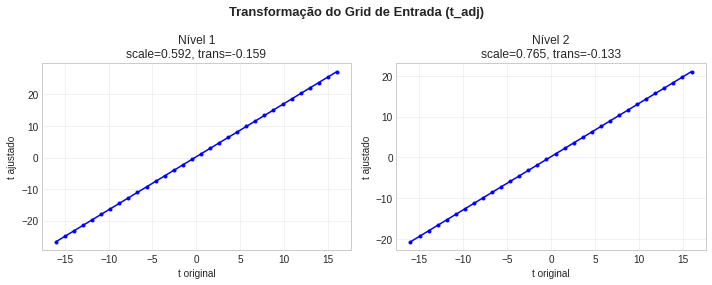

In [16]:
print('='*70)
print('PAR\u00c2METROS APRENDIDOS: Scale e Translation')
print('='*70)

param_data = []
for filt in filters:
    row = {
        'Nível': filt['level'],
        'Scale (softplus)': filt['scale'],
        'Translation': filt['translation'],
        'Kernel Size': filt['kernel_size'],
    }
    param_data.append(row)
    print(f"  Nível {filt['level']}: scale={filt['scale']:.6f}, translation={filt['translation']:.6f}")

param_df = pd.DataFrame(param_data)

# Visualizar a entrada t ajustada para cada nível
fig, axes = plt.subplots(1, n_levels, figsize=(5 * n_levels, 4))
if n_levels == 1:
    axes = [axes]

for i, filt in enumerate(filters):
    K = filt['kernel_size']
    t = np.linspace(-K // 2, K // 2, K)
    t_adj = (t - filt['translation']) / filt['scale']
    
    axes[i].plot(t, t_adj, 'b-o', markersize=3)
    axes[i].set_title(f'Nível {filt["level"]}\nscale={filt["scale"]:.3f}, trans={filt["translation"]:.3f}')
    axes[i].set_xlabel('t original')
    axes[i].set_ylabel('t ajustado')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Transformação do Grid de Entrada (t_adj)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'filter_analysis' / 'scale_translation.png', dpi=150, bbox_inches='tight')
plt.show()

## 14. Energia por Sub-banda (Decomposição de um Sinal de Teste)

Aplicar a DWT aprendida a um sinal de teste e analisar como a energia
é distribuída entre as sub-bandas.

Sub-bandas da DWT aprendida:
  D1: shape=(1, 128, 1), energia=43.1731
  D2: shape=(1, 64, 1), energia=42.2858
  A2: shape=(1, 64, 1), energia=109.6426


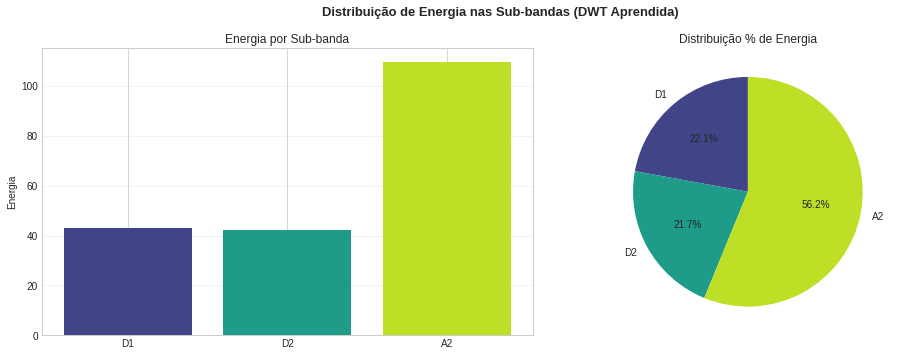


Energia total: 195.1016
Energia do sinal de entrada: 326.2043
Preservação de energia: 59.8%


In [17]:
from config.experiment_config import DATA_DIR

# Carregar sinal de teste
X_test = np.load(DATA_DIR / 'X_test.npy')
x_sample = X_test[:1]  # Uma amostra
x_sample = x_sample[..., np.newaxis]  # Adicionar canal

# wavelet_layer já está em modo 'coeffs' e com pesos carregados
A, details = wavelet_layer(tf.constant(x_sample, dtype=tf.float32))

print('Sub-bandas da DWT aprendida:')
energies = []
for d_idx, D in enumerate(details):
    D_np = D.numpy().flatten()
    e = np.sum(D_np**2)
    energies.append(('D' + str(d_idx+1), e, len(D_np)))
    print(f'  D{d_idx+1}: shape={D.shape}, energia={e:.4f}')

A_np = A.numpy().flatten()
e_a = np.sum(A_np**2)
energies.append(('A' + str(len(details)), e_a, len(A_np)))
print(f'  A{len(details)}: shape={A.shape}, energia={e_a:.4f}')

total_energy = sum(e for _, e, _ in energies)

# Gráfico de barras
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

names = [name for name, _, _ in energies]
vals = [e for _, e, _ in energies]
pcts = [e / total_energy * 100 for e in vals]

colors_sub = plt.cm.viridis(np.linspace(0.2, 0.9, len(names)))

axes[0].bar(names, vals, color=colors_sub)
axes[0].set_title('Energia por Sub-banda')
axes[0].set_ylabel('Energia')
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].pie(pcts, labels=names, autopct='%1.1f%%', colors=colors_sub, startangle=90)
axes[1].set_title('Distribuição % de Energia')

plt.suptitle('Distribuição de Energia nas Sub-bandas (DWT Aprendida)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'filter_analysis' / 'energy_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nEnergia total: {total_energy:.4f}')
e_input = np.sum(x_sample**2)
preservation = total_energy / e_input * 100
print(f'Energia do sinal de entrada: {e_input:.4f}')
print(f'Preservação de energia: {preservation:.1f}%')

## 15. Visualização das Sub-bandas

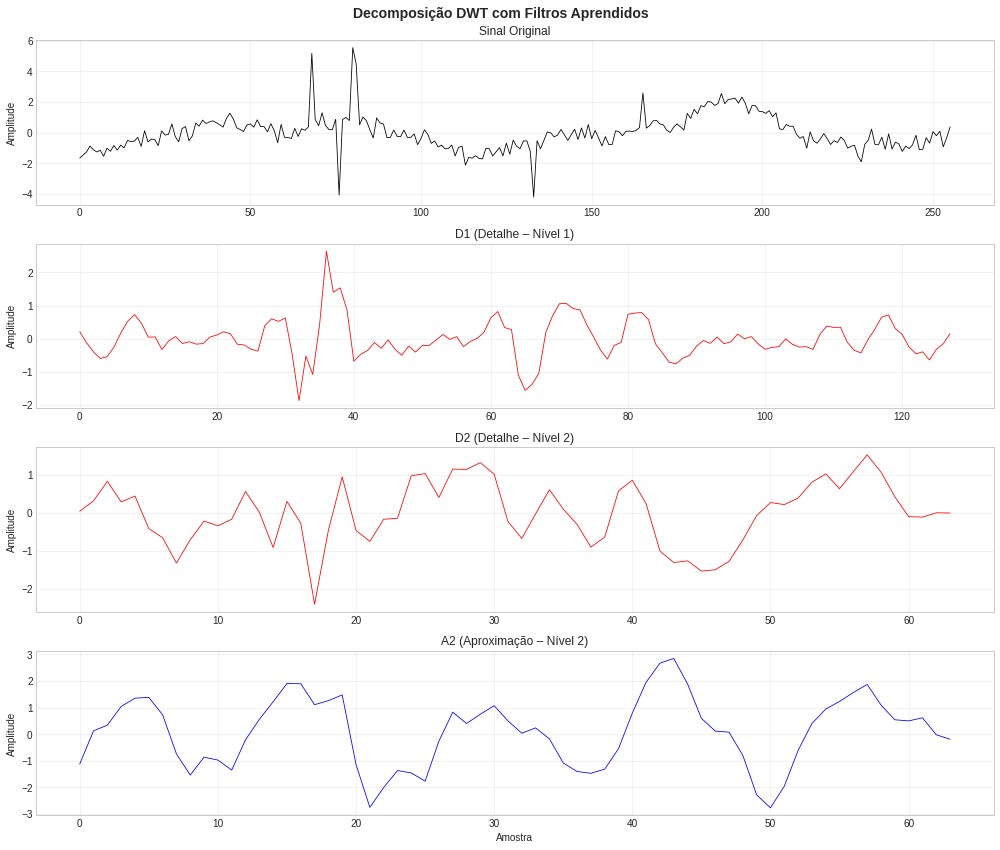

In [18]:
n_sub = len(details) + 2  # original + details + approximation
fig, axes = plt.subplots(n_sub, 1, figsize=(14, 3 * n_sub), sharex=False)

# Sinal original
axes[0].plot(x_sample.flatten(), 'k-', lw=0.8)
axes[0].set_title('Sinal Original')
axes[0].set_ylabel('Amplitude')
axes[0].grid(True, alpha=0.3)

# Detalhes D1, D2, ...
for d_idx, D in enumerate(details):
    ax = axes[d_idx + 1]
    ax.plot(D.numpy().flatten(), 'r-', lw=0.8)
    ax.set_title(f'D{d_idx+1} (Detalhe \u2013 Nível {d_idx+1})')
    ax.set_ylabel('Amplitude')
    ax.grid(True, alpha=0.3)

# Aproximação
axes[-1].plot(A.numpy().flatten(), 'b-', lw=0.8)
axes[-1].set_title(f'A{len(details)} (Aproximação \u2013 Nível {len(details)})')
axes[-1].set_ylabel('Amplitude')
axes[-1].set_xlabel('Amostra')
axes[-1].grid(True, alpha=0.3)

plt.suptitle('Decomposição DWT com Filtros Aprendidos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'filter_analysis' / 'subbands.png', dpi=150, bbox_inches='tight')
plt.show()

## 16. Diferença entre Níveis – Os Filtros São Diferentes?

No `LearnedWaveletDWT1D_QMF`, cada nível tem seu próprio par de filtros
(diferente de wavelets clássicas que reutilizam os mesmos filtros).
Analisar quão diferentes os filtros de cada nível são entre si.

DIFERENÇA ENTRE NÍVEIS (correlação cruzada dos filtros h)

Matriz de Correlação:
         Nível 1  Nível 2
Nível 1   1.0000  -0.1843
Nível 2  -0.1843   1.0000

Matriz de MSE:
          Nível 1   Nível 2
Nível 1  0.000000  0.075308
Nível 2  0.075308  0.000000


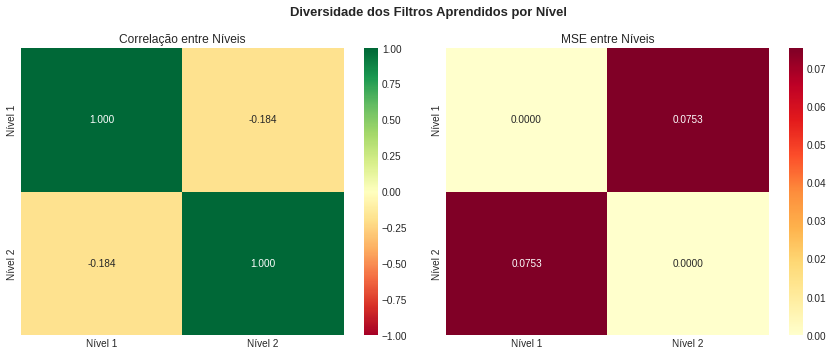

In [19]:
if n_levels > 1:
    print('='*70)
    print('DIFEREN\u00c7A ENTRE N\u00cdVEIS (correlação cruzada dos filtros h)')
    print('='*70)
    
    cross_corr = np.zeros((n_levels, n_levels))
    mse_matrix = np.zeros((n_levels, n_levels))
    
    for i in range(n_levels):
        for j in range(n_levels):
            hi = filters[i]['h']
            hj = filters[j]['h']
            cross_corr[i, j] = np.corrcoef(hi, hj)[0, 1]
            mse_matrix[i, j] = np.mean((hi - hj)**2)
    
    print('\nMatriz de Correlação:')
    labels = [f'Nível {f["level"]}' for f in filters]
    corr_cross_df = pd.DataFrame(cross_corr, index=labels, columns=labels)
    print(corr_cross_df.round(4))
    
    print('\nMatriz de MSE:')
    mse_cross_df = pd.DataFrame(mse_matrix, index=labels, columns=labels)
    print(mse_cross_df.round(6))
    
    # Heatmap
    import seaborn as sns
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    sns.heatmap(cross_corr, annot=True, fmt='.3f', cmap='RdYlGn',
                xticklabels=labels, yticklabels=labels, ax=axes[0],
                vmin=-1, vmax=1)
    axes[0].set_title('Correlação entre Níveis')
    
    sns.heatmap(mse_matrix, annot=True, fmt='.4f', cmap='YlOrRd',
                xticklabels=labels, yticklabels=labels, ax=axes[1])
    axes[1].set_title('MSE entre Níveis')
    
    plt.suptitle('Diversidade dos Filtros Aprendidos por Nível', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'filter_analysis' / 'cross_level_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Apenas 1 nível \u2013 comparação entre níveis não se aplica.')

## 17. Relatório Consolidado

In [20]:
print('\n' + '='*80)
print('\U0001F4CA RELAT\u00d3RIO CONSOLIDADO \u2013 An\u00e1lise dos Filtros Aprendidos')
print('='*80)

summary_rows = []
for i, filt in enumerate(filters):
    h = filt['h']
    g = filt['g']
    K = len(h)
    
    # Admissibilidade
    g_sum = np.sum(g)
    
    # Norma
    h_l2 = np.linalg.norm(h)
    g_l2 = np.linalg.norm(g)
    
    # QMF
    sign = np.array([(-1)**n for n in range(K)])
    g_expected = h[::-1] * sign
    qmf_err = np.max(np.abs(g - g_expected))
    
    # Vanishing moments
    vm = vm_results[i]['vanishing_moments']
    
    # PR deviation
    pr_dev = pr_results[i]['pr_max_deviation_pct']
    
    # Tempo-freq
    dt, df, prod = time_freq_product(h)
    
    col_tf = '\u0394t\u00b7\u0394\u03c9'
    row = {
        'N\u00edvel': filt['level'],
        'sum(g) [adm.]': f'{g_sum:.6f}',
        '||h||_2': f'{h_l2:.4f}',
        '||g||_2': f'{g_l2:.4f}',
        'QMF err': f'{qmf_err:.2e}',
        'PR dev %': f'{pr_dev:.2f}',
        'Van. Moments': vm,
        col_tf: f'{prod:.4f}',
    }
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

# Salvar
summary_df.to_csv(RESULTS_DIR / 'filter_analysis' / 'filter_properties_summary.csv', index=False)
print(f'\n\u2705 Relat\u00f3rio salvo em: {RESULTS_DIR / "filter_analysis" / "filter_properties_summary.csv"}')

print('\n' + '-'*80)
print('INTERPRETA\u00c7\u00c3O:')
print('-'*80)
print('''
\u2022 Admissibilidade (sum(g)\u22480): Garante que o high-pass tem m\u00e9dia zero,
  condi\u00e7\u00e3o necess\u00e1ria para fun\u00e7\u00e3o m\u00e3e wavelet.

\u2022 Normaliza\u00e7\u00e3o: Com normalize_low="sum1", sum(h)=1 (preserva DC).
  A conven\u00e7\u00e3o ortogonal cl\u00e1ssica exige ||h||_2=1.

\u2022 QMF: Garante complementaridade entre low e high pass.
  O erro deve ser \u22480 (garantido por constru\u00e7\u00e3o).

\u2022 Perfect Reconstruction: Desvio <5% indica que o banco de filtros
  permite reconstru\u00e7\u00e3o aproximada do sinal. Desvio grande indica
  que o filtro priorizou discrimina\u00e7\u00e3o sobre reconstru\u00e7\u00e3o.

\u2022 Vanishing Moments: Quanto mais momentos nulos, melhor a capacidade
  de comprimir polin\u00f4mios (db2 tem 2, db4 tem 4).

\u2022 \u0394t\u00b7\u0394\u03c9: Menor = melhor localiza\u00e7\u00e3o. Limite inferior = 0.5 (Gaussiana).

\u2022 Filtros diferentes por n\u00edvel: O modelo pode aprender filtros
  espec\u00edficos para cada escala, ao contr\u00e1rio de wavelets cl\u00e1ssicas.
''')

print('\n\U0001F389 An\u00e1lise de filtros conclu\u00edda!')


📊 RELATÓRIO CONSOLIDADO – Análise dos Filtros Aprendidos
 Nível sum(g) [adm.] ||h||_2 ||g||_2  QMF err PR dev %  Van. Moments  Δt·Δω
     1     -0.008169  1.0267  1.0267 0.00e+00   406.89             0 0.1919
     2     -0.018465  1.0213  1.0213 0.00e+00   441.95             0 0.7634

✅ Relatório salvo em: /home/felipeteodoro/projetos/Doutorado/LearnableWaveletLayer/tests/synthetic/results/filter_analysis/filter_properties_summary.csv

--------------------------------------------------------------------------------
INTERPRETAÇÃO:
--------------------------------------------------------------------------------

• Admissibilidade (sum(g)≈0): Garante que o high-pass tem média zero,
  condição necessária para função mãe wavelet.

• Normalização: Com normalize_low="sum1", sum(h)=1 (preserva DC).
  A convenção ortogonal clássica exige ||h||_2=1.

• QMF: Garante complementaridade entre low e high pass.
  O erro deve ser ≈0 (garantido por construção).

• Perfect Reconstruction: Desvio <5% ind